In [1]:
import pandas as pd

rfm = pd.read_csv("../data/processed/segment_rfm.csv")
rfm.head()

,sender_state,age_group,frequency,monetary_total,avg_txn_value
0,Maharashtra,26-35,13029,17379218,1333.89
1,Uttar Pradesh,26-35,10528,14347595,1362.80
2,Maharashtra,36-45,9472,13390131,1413.65
3,Karnataka,26-35,10464,13272595,1268.41
4,Tamil Nadu,26-35,8979,12210450,1359.89


In [2]:
from sklearn.preprocessing import StandardScaler

features = rfm[["frequency", "monetary_total", "avg_txn_value"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(features_scaled[:5])

[[ 2.65536607  2.6647877   0.42626269]
 [ 1.82823062  1.91817913  0.72623139]
 [ 1.4789883   1.68238106  1.25384843]
 [ 1.80706442  1.65343505 -0.25315449]
 [ 1.31594241  1.39185683  0.69603738]]


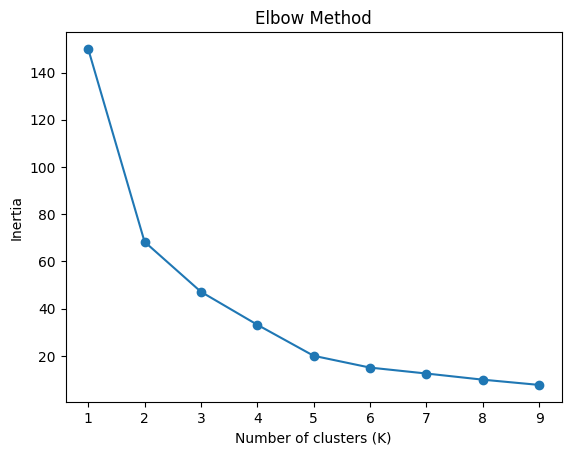

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K=2: silhouette score = 0.455
K=3: silhouette score = 0.454
K=4: silhouette score = 0.457
K=5: silhouette score = 0.501
K=6: silhouette score = 0.500
K=7: silhouette score = 0.498
K=8: silhouette score = 0.500
K=9: silhouette score = 0.502


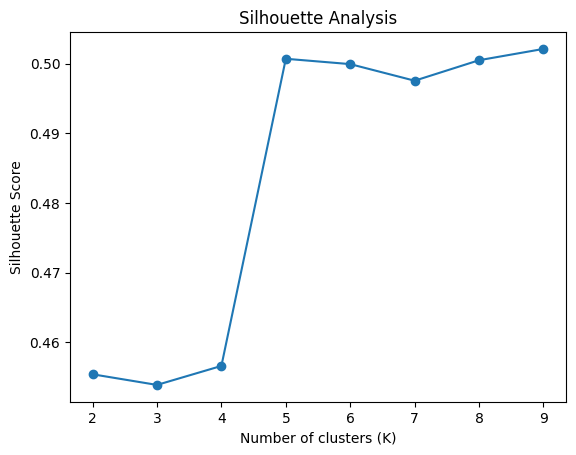

In [4]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 10):  # silhouette needs at least 2 clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}: silhouette score = {score:.3f}")

plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [5]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["cluster"] = kmeans_final.fit_predict(features_scaled)

rfm.sort_values("cluster")

,sender_state,age_group,frequency,monetary_total,avg_txn_value,cluster
7,Uttar Pradesh,36-45,7510,10809480,1439.34,0
14,Andhra Pradesh,26-35,6957,9044641,1300.08,0
13,Delhi,36-45,6326,9097178,1438.06,0
12,Gujarat,26-35,7040,9209622,1308.18,0
11,Rajasthan,26-35,6944,9262568,1333.90,0
10,West Bengal,26-35,7049,9369305,1329.17,0
9,Karnataka,36-45,7437,10416560,1400.64,0
8,Telangana,26-35,7784,10486900,1347.24,0
23,Andhra Pradesh,36-45,5003,7060667,1411.29,0
19,Rajasthan,36-45,5158,7567965,1467.23,0


In [6]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(
    centroids_original,
    columns=["frequency", "monetary_total", "avg_txn_value"]
)
centroid_df.index.name = "cluster"
centroid_df

,frequency,monetary_total,avg_txn_value
cluster,,,
0,6369.642857,8.822618e+06,1389.946429
1,2484.100000,3.311626e+06,1331.824000
2,5880.777778,7.012190e+06,1192.742222
3,1250.900000,1.485530e+06,1186.892000
4,10078.285714,1.333444e+07,1322.760000


In [7]:
rfm["cluster"].value_counts().sort_index()

cluster
0    14
1    10
2     9
3    10
4     7
Name: count, dtype: int64

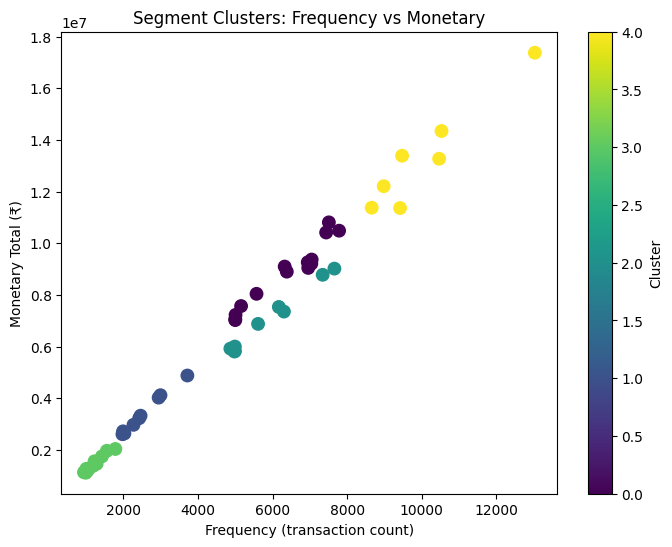

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(rfm["frequency"], rfm["monetary_total"], c=rfm["cluster"], cmap="viridis", s=80)
plt.xlabel("Frequency (transaction count)")
plt.ylabel("Monetary Total (₹)")
plt.title("Segment Clusters: Frequency vs Monetary")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [10]:
rfm.to_csv("../data/processed/segment_clusters_labeled.csv", index=False)